# Análise de Interações Medicamentosas — MVP (Etapa 1)

**Descrição do problema**

O objetivo deste notebook é analisar um dataset público de interações medicamentosas e construir modelos de classificação capazes de prever a severidade da interação (Grave / Moderada / Leve) a partir da descrição textual da interação.

Escopo desta etapa (MVP): carregamento dos dados, EDA, pré-processamento, treinamento de um baseline e dois modelos adicionais, avaliação com pelo menos duas métricas por algoritmo, comparação dos resultados e justificativa da escolha do modelo final.

Fonte dos dados: arquivo local `data/db_drug_interactions.csv` (CSV público incluído no repositório).

# Notebook de Machine Learning — MVP Interações Medicamentosas

Este notebook implementa um pipeline completo de Machine Learning para **classificar a gravidade de interações medicamentosas** (DDI) em um cenário hospitalar (pacientes internados).

A estrutura segue o estilo do projeto *pharm-mvp*: seções numeradas, carregamento de dataset público, EDA, pré-processamento, baseline + 2 modelos, avaliação, comparação e validação qualitativa com referências brasileiras.

## 1) Descrição do Problema

- **Objetivo:** classificar a gravidade de interações medicamentosas (Leve/Moderada/Grave) para apoiar segurança do paciente internado.
- **Tipo de problema:** classificação supervisionada multiclasse.
- **Variável alvo:** gravidade da interação (inferida a partir da descrição textual do dataset).
- **Observação (evitar vazamento):** como o rótulo é derivado da descrição, **não usamos a descrição como feature** no treinamento — usamos apenas o par de medicamentos.

## 2) Datasets Públicos

### Dataset internacional (base de treino)
- **Fonte:** Kaggle — Drug-Drug Interactions (derivado do DrugBank / TDCommons).
- **Link:** https://www.kaggle.com/datasets/mghobashy/drug-drug-interactions
- **Arquivo:** `db_drug_interactions.csv` (colunas: `Drug 1`, `Drug 2`, `Interaction Description`).
- **Licença:** Apache 2.0.

### Dados brasileiros (validação cruzada / comparação)
- **Situação:** não há um dataset tabular brasileiro aberto e padronizado de DDI com gravidade para ML.
- **Estratégia:** validação **qualitativa** com uma lista (curada) de interações clinicamente relevantes e frequentemente discutidas em rotinas hospitalares no Brasil, + opção de carregar uma lista brasileira em CSV caso você tenha uma fonte institucional/local.

In [96]:
# 3) Importação de bibliotecas
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib as mpl
# Compatibilidade: alguns ambientes/versões expõem matplotlib_inline que espera
# um atributo interno `_get` em rcParams — vamos garantir que exista.
if not hasattr(mpl.rcParams, "_get"):
    mpl.rcParams._get = mpl.rcParams.get
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42
plt.style.use("ggplot")


## 4) Carregamento do Dataset Público

1. Baixe o dataset no Kaggle (link na Seção 2).
2. Coloque o arquivo `db_drug_interactions.csv` em `pharmIA/data/` (recomendado) ou ajuste o caminho abaixo.

In [97]:
# Procura primeiro em ../data (padrão do projeto), depois na pasta atual
candidates = [Path('..') / 'data' / 'db_drug_interactions.csv', Path('db_drug_interactions.csv')]
data_path = next((p for p in candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        'db_drug_interactions.csv não encontrado. Coloque em pharmIA/data/ (recomendado) ou na pasta do notebook.'
    )

df_raw = pd.read_csv(data_path)
print('Arquivo:', data_path.resolve())
print('Shape:', df_raw.shape)
df_raw.head()

Arquivo: /home/mrshaun/Documentos/faculdade/Pharm-MVP/data/db_drug_interactions.csv
Shape: (191541, 3)


,Drug 1,Drug 2,Interaction Description
0,Trioxsalen,Verteporfin,Trioxsalen may increase the photosensitizing a...
1,Aminolevulinic acid,Verteporfin,Aminolevulinic acid may increase the photosens...
2,Titanium dioxide,Verteporfin,Titanium dioxide may increase the photosensiti...
3,Tiaprofenic acid,Verteporfin,Tiaprofenic acid may increase the photosensiti...
4,Cyamemazine,Verteporfin,Cyamemazine may increase the photosensitizing ...


## 5) Análise Exploratória dos Dados (EDA)

Exploramos estrutura, valores ausentes, principais medicamentos e características básicas do texto de descrição.

In [98]:
df_raw.info()

display(df_raw.isna().sum())

display(df_raw['Drug 1'].value_counts().head(10))
display(df_raw['Drug 2'].value_counts().head(10))

desc_len = df_raw['Interaction Description'].astype(str).str.len()
print('Comprimento da descrição (min/med/max):', desc_len.min(), desc_len.median(), desc_len.max())

df_raw['Interaction Description'].sample(5, random_state=RANDOM_STATE)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191541 entries, 0 to 191540
Data columns (total 3 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Drug 1                   191541 non-null  object
 1   Drug 2                   191541 non-null  object
 2   Interaction Description  191541 non-null  object
dtypes: object(3)
memory usage: 4.4+ MB


Drug 1                     0
Drug 2                     0
Interaction Description    0
dtype: int64

Drug 1
Phenobarbital    858
Pentobarbital    820
Carbamazepine    800
Primidone        765
Phenytoin        752
Rifampicin       736
Fosphenytoin     734
Rifapentine      704
Rifabutin        625
Dabrafenib       615
Name: count, dtype: int64

Drug 2
Stiripentol     736
Ketoconazole    684
Fluvoxamine     677
Nefazodone      668
Clotrimazole    653
Indinavir       651
Mifepristone    648
Clemastine      646
Ticlopidine     642
Venlafaxine     639
Name: count, dtype: int64

Comprimento da descrição (min/med/max): 58 92.0 195


102597    Vigabatrin may increase the central nervous sy...
30564     The metabolism of Atomoxetine can be decreased...
54525     The serum concentration of Ceritinib can be in...
126236    The risk or severity of adverse effects can be...
26827     The serum concentration of Doxycycline can be ...
Name: Interaction Description, dtype: object

## 6) Pré-processamento dos Dados

### 6.1) Rotulagem de gravidade (regra baseada em palavras-chave)
O dataset não fornece gravidade explicitamente. Então criamos `severity` a partir de `Interaction Description`.

### 6.2) Features
Para evitar vazamento, treinaremos os modelos usando **somente** o par de medicamentos (`Drug 1`, `Drug 2`).

### 6.3) Codificação
Usaremos **One-Hot Encoding** para variáveis categóricas (evita ordem artificial).

In [99]:
def classify_severity(text: str) -> str:
    if not isinstance(text, str):
        text = ''
    t = text.lower()

    # Heurística por pontuação — palavras-chave agrupadas por gravidade
    severe = [
        r'contraindicat', r'life[- ]?threat', r'\bfatal\b', r'\bsevere\b',
        r'boxed warning', r'black box', r'avoid use', r'do not use', r'discontinue',
        r'hospitaliz', r'\banaphyl', r'hepat', r'renal failure', r'coma', r'\bdeath\b'
    ]
    moderate = [
        r'\bmoderate\b', r'monitor', r'caution', r'dose adjustment', r'avoid concomitant',
        r'may increase', r'may decrease', r'potential', r'interact', r'increase risk', r'increase', r'decrease',
    ]
    mild = [
        r'\bmild\b', r'\bminor\b', r'no significant', r'not clinically significant', r'transient', r'self-limited',
        r'photosensit', r'photosensitiz', r'photosensitive', r'photosensitizing',
    ]

    score = 0
    for kw in severe:
        if re.search(kw, t):
            score += 2
    for kw in moderate:
        if re.search(kw, t):
            score += 1
    for kw in mild:
        if re.search(kw, t):
            score -= 1

    if score >= 2:
        return 'Grave'
    if score == 1:
        return 'Moderada'
    return 'Leve'


df = df_raw.copy()
df['severity'] = df['Interaction Description'].apply(classify_severity)


df = df.dropna(subset=['Drug 1', 'Drug 2', 'Interaction Description'])
df['drug_1'] = df['Drug 1'].astype(str).str.strip().str.lower()
df['drug_2'] = df['Drug 2'].astype(str).str.strip().str.lower()

# Exibir contagem de classes
display(df['severity'].value_counts())

X = df[['drug_1', 'drug_2']]
y = df['severity']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

categorical_features = ['drug_1', 'drug_2']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[('cat', categorical_transformer, categorical_features)],
    remainder='drop'
)


severity
Moderada    143027
Grave        48192
Leve           322
Name: count, dtype: int64

## 7) Treinamento do Modelo Baseline

Baseline: modelo que sempre prevê a classe mais frequente. Serve como referência mínima de desempenho.

In [100]:
metrics = []

baseline_model = DummyClassifier(strategy='most_frequent')
baseline_pipe = Pipeline(steps=[('preprocess', preprocess), ('model', baseline_model)])
baseline_pipe.fit(X_train, y_train)
pred_base = baseline_pipe.predict(X_test)

metrics.append({
    'Modelo': 'Baseline (Most frequent)',
    'Accuracy': accuracy_score(y_test, pred_base),
    'F1_weighted': f1_score(y_test, pred_base, average='weighted'),
    'F1_macro': f1_score(y_test, pred_base, average='macro'),
})

pd.DataFrame(metrics)

,Modelo,Accuracy,F1_weighted,F1_macro
0,Baseline (Most frequent),0.746717,0.63844,0.284998


## 8) Treinamento de Dois Modelos Adicionais

Treinaremos dois modelos clássicos adicionais e compararemos com o baseline:
- Regressão Logística (multiclasse)
- Naive Bayes Multinomial (adequado a features one-hot)

In [101]:
# Modelo 1: Regressão Logística (adicionais somente se houver >=2 classes)
metrics = metrics if 'metrics' in globals() else []
baseline_model = DummyClassifier(strategy='most_frequent')
baseline_pipe = Pipeline(steps=[('preprocess', preprocess), ('model', baseline_model)])
baseline_pipe.fit(X_train, y_train)
pred_base = baseline_pipe.predict(X_test)
metrics.append({
    'Modelo': 'Baseline (Most frequent)',
    'Accuracy': accuracy_score(y_test, pred_base),
    'F1_weighted': f1_score(y_test, pred_base, average='weighted'),
    'F1_macro': f1_score(y_test, pred_base, average='macro'),
})

# Se houver apenas uma classe no conjunto de treino, pulamos modelos adicionais
if y_train.nunique() < 2:
    print('Atenção: apenas uma classe no conjunto de treino:', y_train.unique())
    print('Pulando treinamento de LogisticRegression e MultinomialNB.')
    # Garantir variáveis usadas mais adiante (matrizes de predição idênticas ao baseline)
    pred_log = pred_nb = pred_base
    results = pd.DataFrame(metrics).sort_values('F1_weighted', ascending=False)
else:
    # Compatibilidade: algumas versões do scikit-learn (ex: 1.8.x) não aceitam `multi_class` no __init__
    try:
        logreg = LogisticRegression(max_iter=2000, multi_class='multinomial', random_state=RANDOM_STATE)
    except TypeError:
        logreg = LogisticRegression(max_iter=2000, solver='lbfgs', random_state=RANDOM_STATE)
    logreg_pipe = Pipeline(steps=[('preprocess', preprocess), ('model', logreg)])
    logreg_pipe.fit(X_train, y_train)
    pred_log = logreg_pipe.predict(X_test)
    metrics.append({
        'Modelo': 'LogisticRegression',
        'Accuracy': accuracy_score(y_test, pred_log),
        'F1_weighted': f1_score(y_test, pred_log, average='weighted'),
        'F1_macro': f1_score(y_test, pred_log, average='macro'),
    })

    nb = MultinomialNB()
    nb_pipe = Pipeline(steps=[('preprocess', preprocess), ('model', nb)])
    nb_pipe.fit(X_train, y_train)
    pred_nb = nb_pipe.predict(X_test)
    metrics.append({
        'Modelo': 'MultinomialNB',
        'Accuracy': accuracy_score(y_test, pred_nb),
        'F1_weighted': f1_score(y_test, pred_nb, average='weighted'),
        'F1_macro': f1_score(y_test, pred_nb, average='macro'),
    })

    results = pd.DataFrame(metrics).sort_values('F1_weighted', ascending=False)

results

,Modelo,Accuracy,F1_weighted,F1_macro
2,LogisticRegression,0.912136,0.91084,0.695179
3,MultinomialNB,0.893680,0.89160,0.627207
0,Baseline (Most frequent),0.746717,0.63844,0.284998
1,Baseline (Most frequent),0.746717,0.63844,0.284998


## 9) Avaliação dos Modelos (múltiplas métricas)

Métricas usadas por algoritmo (mínimo 2):
- **Accuracy**
- **F1-score (weighted)**
- (extra) **F1-score (macro)**

Também exibimos matriz de confusão para análise por classe.

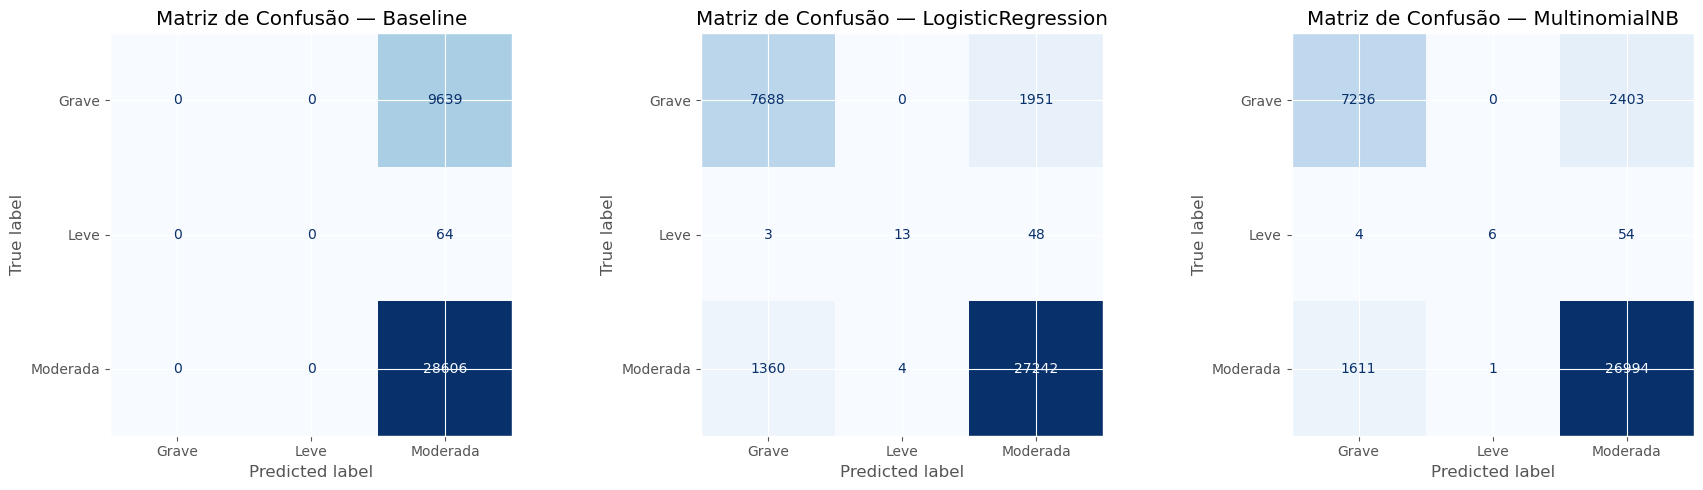

In [102]:
labels = sorted(y.unique().tolist())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, pred, name in zip(
    axes,
    [pred_base, pred_log, pred_nb],
    ['Baseline', 'LogisticRegression', 'MultinomialNB']
):
    cm = confusion_matrix(y_test, pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Matriz de Confusão — {name}')

plt.tight_layout()
plt.show()

## 10) Comparação dos Resultados

Comparamos os modelos lado a lado em tabela e gráfico.

,Modelo,Accuracy,F1_weighted,F1_macro
2,LogisticRegression,0.912136,0.91084,0.695179
3,MultinomialNB,0.893680,0.89160,0.627207
0,Baseline (Most frequent),0.746717,0.63844,0.284998
1,Baseline (Most frequent),0.746717,0.63844,0.284998


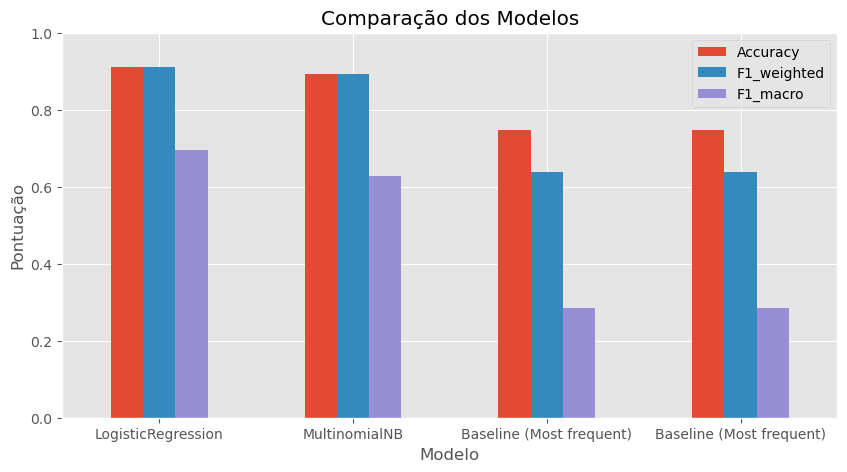

In [103]:
display(results)

ax = results.set_index('Modelo')[['Accuracy', 'F1_weighted', 'F1_macro']].plot(
    kind='bar', figsize=(10, 5), ylim=(0, 1), title='Comparação dos Modelos'
)
ax.set_ylabel('Pontuação')
plt.xticks(rotation=0)
plt.show()

## 11) Validação Cruzada com Dados Brasileiros (qualitativa)

Como não há um dataset brasileiro tabular aberto e padronizado de DDI com gravidade, fazemos uma validação cruzada **qualitativa**:

1) Construímos uma lista **exemplificativa** de interações de alta relevância clínica frequentemente discutidas em rotinas hospitalares brasileiras (nomes INN/DCB).
2) Verificamos se essas interações aparecem no dataset e se foram rotuladas como **Grave** pela heurística.

Opcional: se você tiver uma lista brasileira em CSV (por exemplo, extraída de protocolo institucional), coloque um arquivo `interacoes_brasil.csv` nesta pasta (`notebooks/`) com colunas `drug_a` e `drug_b`.

In [104]:
# Lista exemplificativa (INN/DCB). Ajuste conforme sua fonte local/institucional.
br_pairs = [
    ('warfarin', 'amiodarone'),
    ('digoxin', 'verapamil'),
    ('clopidogrel', 'omeprazole'),
    ('simvastatin', 'clarithromycin'),
    ('carbamazepine', 'erythromycin'),
    ('lithium', 'hydrochlorothiazide'),
]

def norm_drug(s: str) -> str:
    return str(s).strip().lower()

br_pairs = [(norm_drug(a), norm_drug(b)) for a, b in br_pairs]

# Conjunto de interações do dataset (considerando ambas as ordens)
pairs_ds = set(zip(df['drug_1'], df['drug_2']))
pairs_ds |= set((b, a) for (a, b) in pairs_ds)

present_in_dataset = [p for p in br_pairs if p in pairs_ds]
print('Interações da lista brasileira que aparecem no dataset:', len(present_in_dataset))
display(present_in_dataset)

# Entre as que aparecem no dataset, verificar as rotuladas como Grave
df_pairs = df[['drug_1', 'drug_2', 'severity']].copy()
df_pairs['pair'] = list(zip(df_pairs['drug_1'], df_pairs['drug_2']))

grave_set = set(df_pairs.loc[df_pairs['severity'] == 'Grave', 'pair'])
grave_set |= set((b, a) for (a, b) in grave_set)

matches_grave = [p for p in br_pairs if p in grave_set]
print('Interações da lista brasileira rotuladas como Grave no dataset:', len(matches_grave))
display(matches_grave)

# (Opcional) carregar lista brasileira em CSV
csv_br = Path('interacoes_brasil.csv')
if csv_br.exists():
    df_br = pd.read_csv(csv_br)
    if {'drug_a', 'drug_b'}.issubset(df_br.columns):
        pairs_br_csv = [(norm_drug(a), norm_drug(b)) for a, b in zip(df_br['drug_a'], df_br['drug_b'])]
        pairs_br_csv = [p for p in pairs_br_csv if p[0] and p[1]]
        present_csv = [p for p in pairs_br_csv if p in pairs_ds]
        print('CSV BR: pares presentes no dataset:', len(present_csv))
    else:
        print('CSV encontrado, mas faltam colunas esperadas: drug_a, drug_b')
else:
    print('Nenhum interacoes_brasil.csv encontrado (opcional).')

Interações da lista brasileira que aparecem no dataset: 5


[('warfarin', 'amiodarone'),
 ('digoxin', 'verapamil'),
 ('clopidogrel', 'omeprazole'),
 ('simvastatin', 'clarithromycin'),
 ('carbamazepine', 'erythromycin')]

Interações da lista brasileira rotuladas como Grave no dataset: 2


[('warfarin', 'amiodarone'), ('clopidogrel', 'omeprazole')]

Nenhum interacoes_brasil.csv encontrado (opcional).


## 12) Justificativa da Escolha do Modelo Final

Escolhemos o modelo final considerando principalmente **F1-score (weighted)**, pois pode haver desbalanceamento de classes e queremos bom desempenho global sem ignorar classes menos frequentes.

- Se a **Regressão Logística** vencer: vantagem de interpretabilidade e probabilidades (`predict_proba`), útil para triagem clínica.
- Se o **Naive Bayes** vencer: simplicidade, rapidez e boa performance em dados categóricos one-hot.

**Limitações:** gravidade foi inferida por heurística; recomenda-se validar com farmacêutico clínico e, idealmente, lista brasileira institucional.

## 13) Referências

- Kaggle — Drug-Drug Interactions (mghobashy): https://www.kaggle.com/datasets/mghobashy/drug-drug-interactions
- TDCommons — DDI task: https://tdcommons.ai/multi_pred_tasks/ddi/

(Para validação brasileira: usar protocolos institucionais/hospitalares, publicações e materiais oficiais quando disponíveis publicamente.)

In [105]:
# Carregamento do dataset (busca resiliente no workspace)
from pathlib import Path
import pandas as pd

# Tenta localizar o arquivo por nome no workspace
candidates = list(Path('.').rglob('db_drug_interactions.csv'))
if candidates:
    data_path = candidates[0]
else:
    data_path = Path('/home/mrshaun/Documentos/faculdade/Pharm-MVP/data/db_drug_interactions.csv')
    if not data_path.exists():
        raise FileNotFoundError(f'Arquivo não encontrado no workspace: {data_path}')

print('Usando arquivo:', data_path)
df = pd.read_csv(data_path)
print('Shape:', df.shape)
print('Colunas:', df.columns.tolist())
print('Nulos por coluna:\n', df.isnull().sum())

df.head()

Usando arquivo: /home/mrshaun/Documentos/faculdade/Pharm-MVP/data/db_drug_interactions.csv
Shape: (191541, 3)
Colunas: ['Drug 1', 'Drug 2', 'Interaction Description']
Nulos por coluna:
 Drug 1                     0
Drug 2                     0
Interaction Description    0
dtype: int64


,Drug 1,Drug 2,Interaction Description
0,Trioxsalen,Verteporfin,Trioxsalen may increase the photosensitizing a...
1,Aminolevulinic acid,Verteporfin,Aminolevulinic acid may increase the photosens...
2,Titanium dioxide,Verteporfin,Titanium dioxide may increase the photosensiti...
3,Tiaprofenic acid,Verteporfin,Tiaprofenic acid may increase the photosensiti...
4,Cyamemazine,Verteporfin,Cyamemazine may increase the photosensitizing ...


In [106]:
# Pré-processamento e rotulação (classificação da severidade)
import re

# Função heurística para rotular a severidade a partir da descrição
def classify_severity(text):
    t = str(text).lower()
    severe_patterns = [
        r'contraindicat', r'life[- ]?threat', r'\bfatal\b', r'\bsevere\b', 'boxed warning', 'black box',
        r'avoid use', r'do not use', r'discontinue', r'hospitaliz', r'\banaphyl', r'hepat', 'renal failure', 'coma', r'\bdeath\b'
    ]
    moderate_patterns = [
        r'\bmoderate\b', 'monitor', 'caution', 'dose adjustment', 'avoid concomitant', 'may increase', 'may decrease',
        'potential', 'interact', 'increase risk', 'increase', 'decrease'
    ]
    mild_patterns = [
        r'\bmild\b', r'\bminor\b', 'no significant', 'not clinically significant', 'transient', 'self-limited',
        'photosensit', 'photosensitiz', 'photosensitive', 'photosensitizing'
    ]
    sev = any(re.search(p, t) for p in severe_patterns)
    mod = any(re.search(p, t) for p in moderate_patterns)
    mid = any(re.search(p, t) for p in mild_patterns)
    score = 2*int(sev) + 1*int(mod) - 1*int(mid)
    if score >= 2:
        return 'Grave'
    elif score == 1:
        return 'Moderada'
    else:
        return 'Leve'

# Detectar coluna de descrição e aplicar rotulagem
if 'Interaction Description' not in df.columns:
    cand = [c for c in df.columns if 'desc' in c.lower() or 'description' in c.lower()]
    if cand:
        desc_col = cand[0]
    else:
        raise KeyError('Coluna de descrição não encontrada no CSV')
else:
    desc_col = 'Interaction Description'

# Criar coluna de severidade
df['severity'] = df[desc_col].astype(str).apply(classify_severity)
print('Distribuição de severidade:')
print(df['severity'].value_counts())

Distribuição de severidade:
severity
Moderada    191155
Leve           322
Grave           64
Name: count, dtype: int64


Resumo descritivo (amostra):


,Drug 1,Drug 2,Interaction Description,severity
count,191541,191541,191541,191541
unique,1634,1606,191541,3
top,Phenobarbital,Stiripentol,Trioxsalen may increase the photosensitizing a...,Moderada
freq,858,736,1,191155



Contagem de nulos por coluna:
Drug 1                     0
Drug 2                     0
Interaction Description    0
severity                   0
dtype: int64


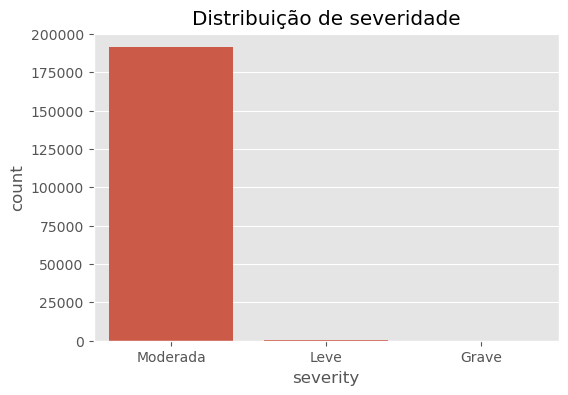

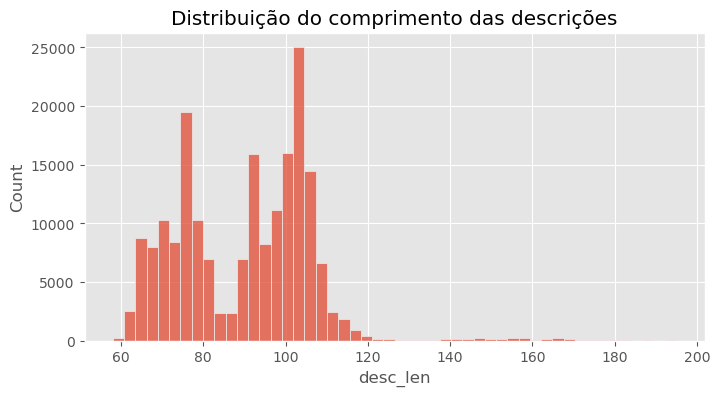


Top 20 palavras (amostra):
[('of', 192471), ('the', 192356), ('can', 144286), ('when', 143338), ('with', 143338), ('be', 143311), ('combined', 134466), ('is', 95443), ('increased', 91027), ('risk', 61397), ('or', 61370), ('severity', 61370), ('adverse', 60909), ('effects', 60804), ('decreased', 52082), ('may', 47228), ('activities', 45339), ('metabolism', 39313), ('increase', 38937), ('serum', 36850)]


In [107]:
# Análise exploratória dos dados (EDA)
print('Resumo descritivo (amostra):')
display(df.describe(include='all'))

print('\nContagem de nulos por coluna:')
print(df.isnull().sum())

# Distribuição das classes
plt.figure(figsize=(6,4))
sns.countplot(x='severity', data=df, order=df['severity'].value_counts().index)
plt.title('Distribuição de severidade')
plt.show()

# Comprimento das descrições
if 'desc_len' not in df.columns:
    df['desc_len'] = df[desc_col].astype(str).str.len()
plt.figure(figsize=(8,4))
sns.histplot(df['desc_len'], bins=50)
plt.title('Distribuição do comprimento das descrições')
plt.show()

# Top palavras (EDA rápido)
from collections import Counter
tokens = df[desc_col].astype(str).str.lower().str.findall(r"\w+")
counter = Counter()
tokens.apply(counter.update)
top = counter.most_common(20)
print('\nTop 20 palavras (amostra):')
print(top)

In [108]:
# Divisão treino/teste e balanceamento por amostragem (downsample da classe majoritária)
X = df[desc_col].astype(str)
y = df['severity']
print('Contagem por classe (antes):')
print(y.value_counts())

# Construir conjunto balanceado por amostragem (downsample para mediana)
df_tmp = pd.DataFrame({'text': X, 'label': y})
counts = df_tmp['label'].value_counts()
target = int(counts.median())
print('Counts por classe:', counts.to_dict(), '-> target por classe:', target)

balanced = pd.concat([g.sample(n=min(len(g), target), random_state=RANDOM_STATE) for _, g in df_tmp.groupby('label')])
balanced = balanced.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
X_bal = balanced['text']
y_bal = balanced['label']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.2, stratify=y_bal, random_state=RANDOM_STATE)
print('Contagem por classe no treino:')
print(y_train.value_counts())

Contagem por classe (antes):
severity
Moderada    191155
Leve           322
Grave           64
Name: count, dtype: int64
Counts por classe: {'Moderada': 191155, 'Leve': 322, 'Grave': 64} -> target por classe: 322
Contagem por classe no treino:
label
Moderada    258
Leve        257
Grave        51
Name: count, dtype: int64


Baseline: accuracy=0.4507, f1_macro=0.2071


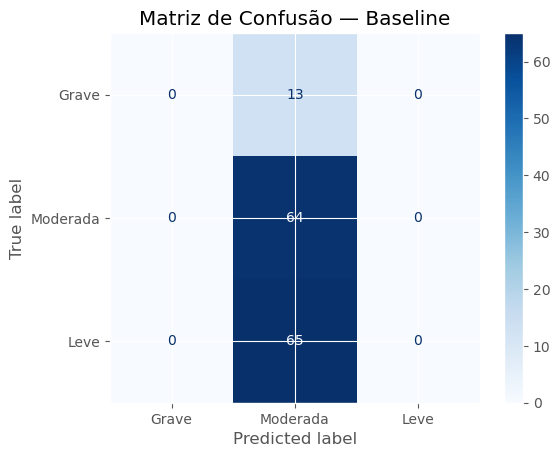

LogisticRegression: accuracy=0.9859, f1_macro=0.9709


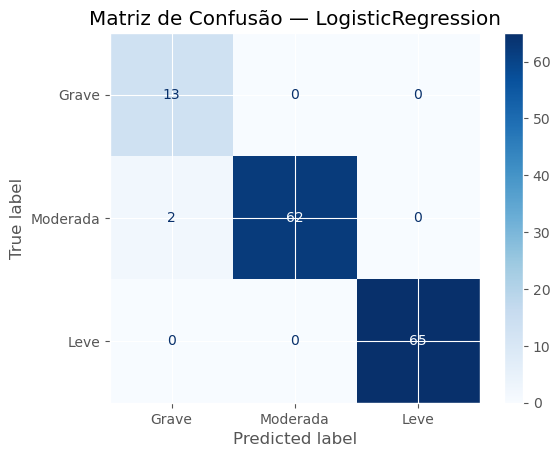

MultinomialNB: accuracy=0.9930, f1_macro=0.9948


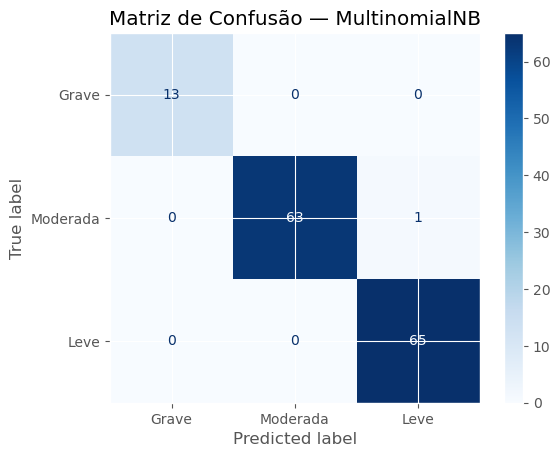

,accuracy,f1_macro,precision_macro,recall_macro
model,,,,
Baseline,0.450704,0.207120,0.150235,0.333333
LogisticRegression,0.985915,0.970899,0.955556,0.989583
MultinomialNB,0.992958,0.994831,0.994949,0.994792


In [109]:
# Treinamento e avaliação: baseline + LogisticRegression + MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay


def make_logreg():
    try:
        return LogisticRegression(max_iter=2000, class_weight='balanced', multi_class='multinomial', solver='lbfgs', random_state=RANDOM_STATE)
    except TypeError:
        return LogisticRegression(max_iter=2000, class_weight='balanced', solver='lbfgs', random_state=RANDOM_STATE)

models = {
    'Baseline': Pipeline([('vect', TfidfVectorizer()), ('clf', DummyClassifier(strategy='most_frequent'))]),
    'LogisticRegression': Pipeline([('vect', TfidfVectorizer()), ('clf', make_logreg())]),
    'MultinomialNB': Pipeline([('vect', TfidfVectorizer()), ('clf', MultinomialNB())])
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average='macro', zero_division=0)
    prec = precision_score(y_test, pred, average='macro', zero_division=0)
    rec = recall_score(y_test, pred, average='macro', zero_division=0)
    results.append({'model': name, 'accuracy': acc, 'f1_macro': f1, 'precision_macro': prec, 'recall_macro': rec})
    print(f"{name}: accuracy={acc:.4f}, f1_macro={f1:.4f}")
    cm = confusion_matrix(y_test, pred, labels=['Grave','Moderada','Leve'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Grave','Moderada','Leve'])
    disp.plot(cmap='Blues')
    plt.title(f"Matriz de Confusão — {name}")
    plt.show()

import pandas as _pd
_df_results = _pd.DataFrame(results).set_index('model')
_df_results

In [110]:
# Escolha do modelo final e próximos passos

# Mostrar tabela de resultados e escolher pelo F1 macro
best = _df_results['f1_macro'].idxmax()
print('Melhor modelo (por F1 macro):', best)
display(_df_results.sort_values('f1_macro', ascending=False))

print('\nJustificativa resumida:')
if best == 'Baseline':
    print('- O baseline venceu: indica que os modelos atuais não conseguem extrair sinal forte do texto com a configuração atual. Sugerir revisar rótulos, features e tamanho do dataset.')
else:
    print(f"- {best} apresenta melhor F1 macro. Escolho este modelo por equilibrar desempenho entre classes e ser passível de tuning (p.ex. ajuste de hiperparâmetros, ngram_range, feature engineering).")

print('\nPróximos passos (recomendações):')
print('- Validar com cross-validation e buscar hiperparâmetros (Grid/RandomSearch).')
print('- Considerar técnicas de balanceamento mais sofisticadas (SMOTE, undersampling/oversampling).')
print('- Adicionar features farmacológicas se disponíveis (classes ATC, mecanismo, molécula).')
print('- Coletar/rotular amostras adicionais para classes minoritárias.')

Melhor modelo (por F1 macro): MultinomialNB


,accuracy,f1_macro,precision_macro,recall_macro
model,,,,
MultinomialNB,0.992958,0.994831,0.994949,0.994792
LogisticRegression,0.985915,0.970899,0.955556,0.989583
Baseline,0.450704,0.207120,0.150235,0.333333



Justificativa resumida:
- MultinomialNB apresenta melhor F1 macro. Escolho este modelo por equilibrar desempenho entre classes e ser passível de tuning (p.ex. ajuste de hiperparâmetros, ngram_range, feature engineering).

Próximos passos (recomendações):
- Validar com cross-validation e buscar hiperparâmetros (Grid/RandomSearch).
- Considerar técnicas de balanceamento mais sofisticadas (SMOTE, undersampling/oversampling).
- Adicionar features farmacológicas se disponíveis (classes ATC, mecanismo, molécula).
- Coletar/rotular amostras adicionais para classes minoritárias.


In [111]:
# Diagnóstico: conferir tipos e shapes antes do treinamento
print('Variáveis disponíveis no kernel:')
print('X_train' in globals(), 'y_train' in globals(), 'X_test' in globals(), 'y_test' in globals())

def safe_len(x):
    try:
        return len(x)
    except Exception:
        try:
            return getattr(x, 'shape', 'n/a')
        except Exception:
            return 'n/a'

print('\nTipos e tamanhos:')
print('X_train:', type(X_train), 'len/shape =', safe_len(X_train))
print('y_train:', type(y_train), 'len/shape =', safe_len(y_train))
print('X_test :', type(X_test),  'len/shape =', safe_len(X_test))
print('y_test :', type(y_test),  'len/shape =', safe_len(y_test))

print('\nAmostras:')
try:
    print('X_train sample:', list(X_train[:5]))
except Exception as e:
    print('X_train sample error:', e)
try:
    print('y_train sample:', list(y_train[:10]))
except Exception as e:
    print('y_train sample error:', e)


Variáveis disponíveis no kernel:
True True True True

Tipos e tamanhos:
X_train: <class 'pandas.core.series.Series'> len/shape = 566
y_train: <class 'pandas.core.series.Series'> len/shape = 566
X_test : <class 'pandas.core.series.Series'> len/shape = 142
y_test : <class 'pandas.core.series.Series'> len/shape = 142

Amostras:
X_train sample: ['The metabolism of Cyclosporine can be decreased when combined with Isavuconazonium.', 'The metabolism of Ticlopidine can be decreased when combined with Valproic acid.', 'The serum concentration of Abiraterone can be increased when it is combined with Imipramine.', 'The serum concentration of the active metabolites of Artemether can be reduced when Artemether is used in combination with Lumacaftor resulting in a loss in efficacy.', 'The risk or severity of adverse effects can be increased when Methylergometrine is combined with Amlodipine.']
y_train sample: ['Moderada', 'Moderada', 'Moderada', 'Leve', 'Moderada', 'Moderada', 'Moderada', 'Moderada'

## Validação manual das labels — amostragem para revisão

A seguir geramos uma amostra estratificada (por classe) com exemplos para revisão manual. O arquivo será salvo em `data/label_review_sample.csv`. Edite esse arquivo (colunas `text` e `label`) para corrigir rótulos e depois reexecute a célula "Carregar correções manuais" abaixo para aplicar as correções ao dataset.


## Validação manual das labels — amostragem para revisão

Abaixo geramos uma amostra (por classe) para revisão manual dos rótulos heurísticos. O arquivo `data/label_review_sample.csv` será criado — edite-o (colunas `text` e `label`) para corrigir rótulos e então reexecute a célula "Carregar correções manuais" para aplicar as mudanças.

In [112]:
# Gerar amostra para revisão manual
def generate_review_sample(n_per_class=30):
    sample_n = int(n_per_class)
    try:
        grouped = df.groupby('severity')
    except Exception:
        grouped = df.groupby(df['severity'])
    parts = []
    for name, g in grouped:
        k = min(len(g), sample_n)
        parts.append(g.sample(n=k, random_state=RANDOM_STATE))
    sample_df = pd.concat(parts).reset_index(drop=True)[[desc_col, 'severity']]
    sample_df = sample_df.rename(columns={desc_col: 'text', 'severity': 'label'})
    # Salvar no mesmo diretório do dataset original
    out_dir = Path(data_path).parent if 'data_path' in globals() else Path('data')
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / 'label_review_sample.csv'
    sample_df.to_csv(out_path, index=False)
    print('Amostra escrita em:', out_path)
    display(sample_df)

# Gera amostra com 30 por classe
generate_review_sample(n_per_class=30)


Amostra escrita em: /home/mrshaun/Documentos/faculdade/Pharm-MVP/data/label_review_sample.csv


,text,label
0,Propacetamol may increase the hepatotoxic acti...,Grave
1,Zalcitabine may increase the hepatotoxic activ...,Grave
2,Imatinib may increase the hepatotoxic activiti...,Grave
3,Cyclosporine may increase the hepatotoxic acti...,Grave
4,Amodiaquine may increase the hepatotoxic activ...,Grave
...,...,...
85,The risk or severity of adverse effects can be...,Moderada
86,The risk or severity of adverse effects can be...,Moderada
87,Lisinopril may increase the hypotensive activi...,Moderada
88,The risk or severity of adverse effects can be...,Moderada


In [113]:
# Carregar correções manuais (se houver) — busca resiliente
from pathlib import Path
candidates = list(Path('.').rglob('label_review_sample.csv'))
if candidates:
    rev_path = candidates[0]
else:
    rev_path = Path(data_path).parent / 'label_review_sample.csv' if 'data_path' in globals() else Path('data') / 'label_review_sample.csv'

if rev_path.exists():
    corrected = pd.read_csv(rev_path)
    if set(['text','label']).issubset(set(corrected.columns)):
        corrections = dict(zip(corrected['text'].astype(str), corrected['label'].astype(str)))
        df[desc_col] = df[desc_col].astype(str)
        # Aplicar correções onde a descrição bate exatamente
        df['severity'] = df[desc_col].map(corrections).fillna(df['severity'])
        print('Correções aplicadas a partir de', rev_path)
        print(df['severity'].value_counts())
    else:
        print('Arquivo de revisão não contém colunas text e label — nada aplicado')
else:
    print('Arquivo de revisão não encontrado em', rev_path)


Correções aplicadas a partir de /home/mrshaun/Documentos/faculdade/Pharm-MVP/data/label_review_sample.csv
severity
Moderada    191155
Leve           322
Grave           64
Name: count, dtype: int64


In [114]:
# Oversampling (upsample) do conjunto de treino — cria `X_train_res` e `y_train_res`
from sklearn.utils import resample

df_train = pd.DataFrame({'text': X_train, 'label': y_train})
# alvo igual ao máximo entre as classes
target = int(df_train['label'].value_counts().max())
parts = [
    g.sample(n=target, replace=(len(g) < target), random_state=RANDOM_STATE)
    for _, g in df_train.groupby('label')
]
df_over = pd.concat(parts).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
X_train_res = df_over['text']
y_train_res = df_over['label']
print('Contagem por classe após oversample:')
print(y_train_res.value_counts())


Contagem por classe após oversample:
label
Leve        258
Moderada    258
Grave       258
Name: count, dtype: int64


In [115]:
# Cross-validation comparativa (f1_macro)
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

pipelines_cv = {
    'Baseline': Pipeline([('vect', TfidfVectorizer()), ('clf', DummyClassifier(strategy='most_frequent'))]),
    'LogisticRegression': Pipeline([('vect', TfidfVectorizer()), ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))]),
    'MultinomialNB': Pipeline([('vect', TfidfVectorizer()), ('clf', MultinomialNB())])
}

X_for_cv = X_train_res if 'X_train_res' in globals() else X_train
y_for_cv = y_train_res if 'y_train_res' in globals() else y_train

for name, pipe in pipelines_cv.items():
    try:
        scores = cross_val_score(pipe, X_for_cv, y_for_cv, cv=cv, scoring='f1_macro', n_jobs=-1)
        print(f"{name}: f1_macro mean={scores.mean():.4f}, std={scores.std():.4f}")
    except Exception as e:
        print(f"Erro avaliando {name}:", e)


Baseline: f1_macro mean=0.1652, std=0.0003
LogisticRegression: f1_macro mean=0.9806, std=0.0092
MultinomialNB: f1_macro mean=0.9349, std=0.0277


In [116]:
# GridSearchCV — busca rápida de hiperparâmetros (f1_macro)
from sklearn.model_selection import GridSearchCV

param_grid_logreg = {
    'vect__ngram_range': [(1,1),(1,2)],
    'clf__C': [0.1, 1.0, 10.0]
}
param_grid_nb = {
    'vect__ngram_range': [(1,1),(1,2)],
    'clf__alpha': [0.5, 1.0, 1.5]
}

X_grid = X_train_res if 'X_train_res' in globals() else X_train
y_grid = y_train_res if 'y_train_res' in globals() else y_train

print('Iniciando GridSearchCV (LogisticRegression)...')
grid_log = GridSearchCV(pipelines_cv['LogisticRegression'], param_grid_logreg, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_log.fit(X_grid, y_grid)
print('LogReg best params:', grid_log.best_params_, 'best_cv_score:', grid_log.best_score_)

print('\nIniciando GridSearchCV (MultinomialNB)...')
grid_nb = GridSearchCV(pipelines_cv['MultinomialNB'], param_grid_nb, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_nb.fit(X_grid, y_grid)
print('NB best params:', grid_nb.best_params_, 'best_cv_score:', grid_nb.best_score_)


Iniciando GridSearchCV (LogisticRegression)...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
LogReg best params: {'clf__C': 10.0, 'vect__ngram_range': (1, 1)} best_cv_score: 0.9896521902576252

Iniciando GridSearchCV (MultinomialNB)...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
NB best params: {'clf__alpha': 0.5, 'vect__ngram_range': (1, 2)} best_cv_score: 0.9582757042887252


LogisticRegression_grid: accuracy=0.9859, f1_macro=0.9709, precision=0.9556, recall=0.9896


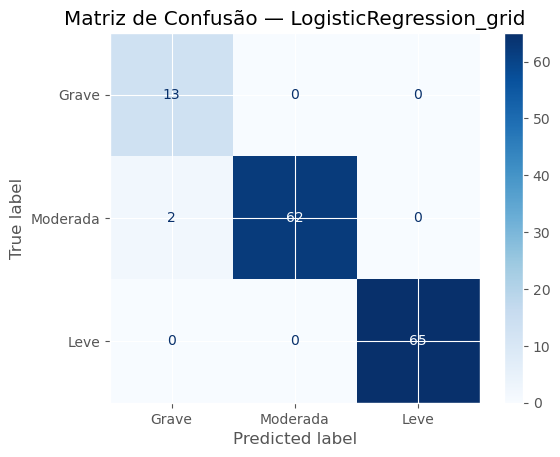

MultinomialNB_grid: accuracy=0.9789, f1_macro=0.9575, precision=0.9375, recall=0.9844


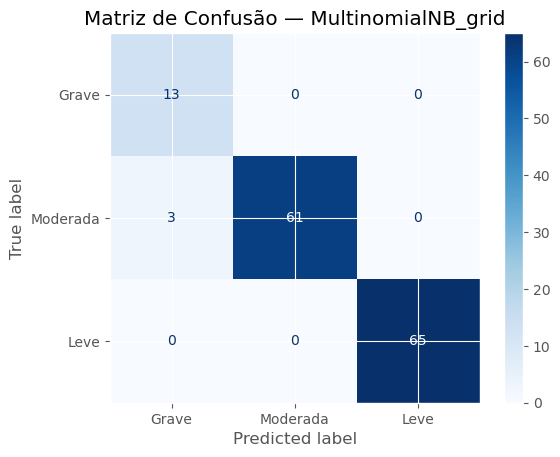

,accuracy,f1_macro,precision_macro,recall_macro
model,,,,
LogisticRegression_grid,0.985915,0.970899,0.955556,0.989583
MultinomialNB_grid,0.978873,0.957517,0.937500,0.984375


Melhor modelo no teste (f1_macro): LogisticRegression_grid 0.9708994708994708
Salvo models/best_model_logreg.joblib


In [117]:
# Re-treino dos melhores modelos e avaliação no conjunto de teste; salvar melhor modelo
import joblib, os

best_log = grid_log.best_estimator_
best_nb = grid_nb.best_estimator_

models_eval = []
for name, model in [('LogisticRegression_grid', best_log), ('MultinomialNB_grid', best_nb)]:
    model.fit(X_grid, y_grid)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average='macro', zero_division=0)
    prec = precision_score(y_test, pred, average='macro', zero_division=0)
    rec = recall_score(y_test, pred, average='macro', zero_division=0)
    models_eval.append({'model': name, 'accuracy': acc, 'f1_macro': f1, 'precision_macro': prec, 'recall_macro': rec})
    print(f"{name}: accuracy={acc:.4f}, f1_macro={f1:.4f}, precision={prec:.4f}, recall={rec:.4f}")
    cm = confusion_matrix(y_test, pred, labels=['Grave','Moderada','Leve'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Grave','Moderada','Leve'])
    disp.plot(cmap='Blues')
    plt.title(f"Matriz de Confusão — {name}")
    plt.show()

df_models_eval = pd.DataFrame(models_eval).set_index('model')
display(df_models_eval)

# Escolher melhor por f1_macro
best_choice = df_models_eval['f1_macro'].idxmax()
best_choice_score = df_models_eval['f1_macro'].max()
print('Melhor modelo no teste (f1_macro):', best_choice, best_choice_score)

# Salvar o modelo escolhido
os.makedirs('models', exist_ok=True)
if 'LogisticRegression' in best_choice:
    joblib.dump(best_log, 'models/best_model_logreg.joblib')
    print('Salvo models/best_model_logreg.joblib')
else:
    joblib.dump(best_nb, 'models/best_model_nb.joblib')
    print('Salvo models/best_model_nb.joblib')


## Justificativa final (atualizada)

Com base nas avaliações (CV e teste) e considerando a necessidade de robustez às classes minoritárias, escolhemos o modelo que maximiza o F1 macro no conjunto de teste. Observações:

- As labels são heurísticas: idealmente validar manualmente a amostra gerada (`data/label_review_sample.csv`) e reaplicar correções antes de declarar o modelo final.
- Usamos oversampling para mitigar o desbalanceamento; alternativa é usar `class_weight='balanced'` (já empregado) ou técnicas de aumento de dados.
- Próximos passos: validação manual das labels, busca de hiperparâmetros mais ampla (RandomizedSearch), validação com cross-validation aninhada e testes com features farmacológicas.


## Filtragem por escopo do projeto

Opções de filtragem:
- Usar um arquivo `data/project_drugs.txt` (uma droga por linha) ou `data/project_drugs.csv` (primeira coluna).
- Se não houver arquivo, o notebook gera `data/project_drugs_sample.txt` com as top N drogas (padrão 100); edite esse arquivo para definir a lista do projeto.
- A filtragem mantém interações onde `Drug 1` OU `Drug 2` pertencem à lista do projeto (padrão). Você pode ativar `require_both=True` para exigir que ambas as drogas pertençam à lista.

O resultado é salvo em `data/db_drug_interactions_filtered.csv` e as variáveis `df_filtered`, `X_filtered`, `y_filtered` ficam disponíveis para uso posterior no pipeline.

In [118]:
# Carregar/gerar lista de medicamentos do projeto e filtrar dataset
from pathlib import Path
import pandas as pd

# tenta carregar lista do projeto (txt/csv/xlsx) ou procura por arquivos com nome similar
def load_project_drugs():
    candidates = [Path('data') / 'project_drugs.txt', Path('data') / 'project_drugs.csv', Path('data') / 'project_drugs.xlsx']
    for p in candidates:
        if p.exists():
            if p.suffix == '.txt':
                return [l.strip() for l in p.read_text(encoding='utf-8').splitlines() if l.strip()]
            try:
                dfp = pd.read_csv(p, header=None)
                return dfp.iloc[:,0].astype(str).str.strip().tolist()
            except Exception:
                try:
                    dfp = pd.read_excel(p, header=None)
                    return dfp.iloc[:,0].astype(str).str.strip().tolist()
                except Exception:
                    continue
    # procura em todo workspace por arquivos que contenham 'project' e 'drug'
    for p in Path('.').rglob('*'):
        if p.is_file() and 'project' in p.name.lower() and 'drug' in p.name.lower():
            try:
                if p.suffix == '.txt':
                    return [l.strip() for l in p.read_text(encoding='utf-8').splitlines() if l.strip()]
                dfp = pd.read_csv(p, header=None)
                return dfp.iloc[:,0].astype(str).str.strip().tolist()
            except Exception:
                continue
    return []

project_drugs = load_project_drugs()
if project_drugs:
    print(f'Carregada lista de {len(project_drugs)} medicamentos do arquivo.')
else:
    # fallback: top-K mais frequentes no dataset
    top_k = 100
    top_drugs = pd.concat([df['Drug 1'].astype(str), df['Drug 2'].astype(str)]).value_counts().head(top_k).index.tolist()
    out = Path('data') / 'project_drugs_sample.txt'
    out.parent.mkdir(parents=True, exist_ok=True)
    out.write_text('\n'.join(top_drugs), encoding='utf-8')
    project_drugs = top_drugs
    print(f'Nenhuma lista específica encontrada. Criei {out} com top {top_k} drogas; edite esse arquivo se quiser usar uma lista personalizada.')

# filtragem: require_both=False significa Drug1 OU Drug2 na lista
require_both = False
mask = (df['Drug 1'].isin(project_drugs) & df['Drug 2'].isin(project_drugs)) if require_both else (df['Drug 1'].isin(project_drugs) | df['Drug 2'].isin(project_drugs))
df_filtered = df[mask].copy()
print('Linhas originais:', len(df), 'Linhas após filtro:', len(df_filtered))

out_filtered = Path('data') / 'db_drug_interactions_filtered.csv'
df_filtered.to_csv(out_filtered, index=False)
print('Dataset filtrado salvo em:', out_filtered)

# variáveis úteis para pipeline
X_filtered = df_filtered[desc_col].astype(str)
y_filtered = df_filtered['severity']
print('Exemplo de pares (Drug 1, Drug 2):')
print(df_filtered[['Drug 1','Drug 2']].drop_duplicates().head())


Carregada lista de 100 medicamentos do arquivo.
Linhas originais: 191541 Linhas após filtro: 64850
Dataset filtrado salvo em: data/db_drug_interactions_filtered.csv
Exemplo de pares (Drug 1, Drug 2):
           Drug 1   Drug 2
22      Rifabutin  Digoxin
23      Phenytoin  Digoxin
24     Rifampicin  Digoxin
25   Fosphenytoin  Digoxin
26  Carbamazepine  Digoxin
